# **Sentiment Analysis for Movie Reviews**

### **DATA UNDERSTANDING**

In [44]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [45]:
# Download Stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
# Load Dataset
movie_data = pd.read_csv('/content/IMDB.csv', on_bad_lines='skip', engine='python')

In [47]:
# Basic Cleaning dataset
movie_data['review'] = movie_data['review'].str.replace('<br />', '')
movie_data['review'] = movie_data['review'].str.strip()
movie_data = movie_data.drop_duplicates()

In [48]:
# View Dataset
movie_data.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [49]:
# Size of Dataset
movie_data.shape

(49581, 2)

In [50]:
# Columns in Dataset
movie_data.columns

Index(['review', 'sentiment'], dtype='object')

In [51]:
# Datatypes of Dataset
movie_data.dtypes

,0
review,object
sentiment,object


In [52]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49581 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     49581 non-null  object
 1   sentiment  49581 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [53]:
# Before Encoding
print(movie_data['sentiment'].unique())

['positive' 'negative']


In [54]:
#  Binary Encoding
movie_data['sentiment'] = movie_data['sentiment'].map({'positive': 1,'negative':0})

In [55]:
# After Encoding
print(movie_data['sentiment'].unique())

[1 0]


## **Text Preprocessing**

In [56]:
# basic cleaning function
import re
import string
def text_clean(review_text):
  review_text = review_text.lower()
  review_text = re.sub(r'\d+','', review_text)
  review_text = review_text.translate(str.maketrans('','', string.punctuation))
  review_text = [word for word in review_text.split() if word not in stop_words]
  return review_text

# Functiona call and result stored in new DataFrame
movie_data['cleaned_review_data'] = movie_data['review'].apply(text_clean) # apply to function name

## **Feature Extraction- TF-IDF (Vectorization)**

In [57]:
# Convert text to numerical features
# TF-IDF vectorizer
vectorizier = TfidfVectorizer()
X = vectorizier.fit_transform(movie_data['cleaned_review_data'].apply(lambda x: ' '.join(x)))
y = movie_data['sentiment']

In [58]:
# X → features (TF-IDF vectors) → shape (n_samples, n_features)
# y → labels → shape (n_samples,)
# They must have the same number of rows to train a model

print(X.shape)
print(y.shape)

(49581, 214451)
(49581,)


**Interpreting**

(49581, 214451)

* 49581 → number of reviews (rows in your dataset)
* 214451 → number of unique words / tokens after preprocessing (columns in TF-IDF)

So your TF-IDF matrix has 49,581 reviews × 214,451 unique words.

## **Machine Learning**

In [59]:
# Train,Test Split

X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [60]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)

# The number of test samples: ntest​=ntotal​×test_size
# The number of train samples: ntrain​=ntotal​−ntest​
# Eg:
# ntest ​= 49,581 × 0.3 = 14,874.3
# ntrain ​= 49,581 − 14,874 = 34,707

(39664, 214451)
(39664,)
(9917, 214451)


### **1. Logistic Regression**

In [61]:
# Model Selection
model = LogisticRegression()
model.fit(X_train,y_train)

# Predictions
y_predict = model.predict(X_test)

Accuracy Score is: 0.8911969345568216
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4958
           1       0.88      0.90      0.89      4959

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



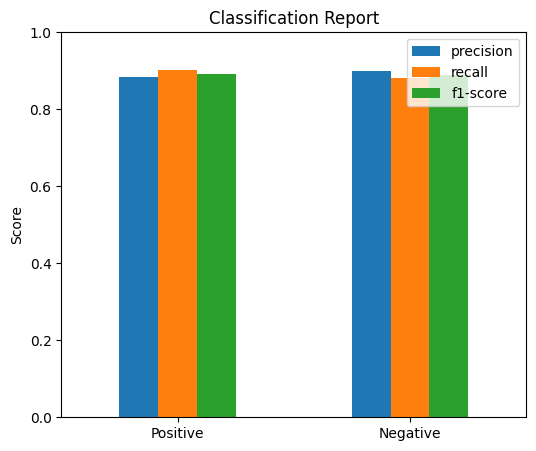

[[4364  594]
 [ 485 4474]]


In [62]:
# Evaluation
# 1.Accuracy
accuracy = accuracy_score(y_test, y_predict)
print('Accuracy Score is:',accuracy)

# 2.Classififcation Report
report_dict = classification_report(y_test, y_predict, output_dict=True)
print(classification_report(y_test, y_predict))

# Plot Classification Report
data_report = pd.DataFrame(report_dict).transpose()
data = data_report.loc[['1','0'],['precision','recall','f1-score']]

data.index = ['Positive','Negative']

data.plot(kind='bar', figsize=(6,5))
plt.title("Classification Report")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(loc='upper right')
plt.show()

# 3.Confusion Matrix
conf_matrix = confusion_matrix(y_test,y_predict)
print(conf_matrix)

**Definition:**

* Precision → TP / (TP + FP)
* Recall → TP / (TP + FN)
* F1-Score → 2 *  (Precision * Recall / Precision * Recall)

**Support:**

Number of actual samples in that class

* Class 0 → 4958 samples
* Class 1 → 4959 samples


**Explanation:**

* 4364 → True Negatives (TN): Actual 0 predicted as 0
* 594 → False Positives (FP): Actual 0 predicted as 1
* 485 → False Negatives (FN): Actual 1 predicted as 0
* 4474 → True Positives (TP): Actual 1 predicted as 1

From confusion matrix:

* accuracy = TP+TN / Total Samples
* Macro avg → average of class 0 & 1 metrics equally
* Weighted avg → average weighted by support (number of samples)



### **2. Support Vector Machine**

In [63]:
# import libraries
from sklearn.svm import LinearSVC
model = LinearSVC()

# Prediction
model.fit(X_train,y_train)
prdiction = model.predict(X_test)

# Evaluation
print(accuracy_score(y_test,prdiction))
print(classification_report(y_test,prdiction))
print(confusion_matrix(y_test,prdiction))


0.8924069779167086
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4958
           1       0.89      0.90      0.89      4959

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917

[[4379  579]
 [ 488 4471]]
